# Consumer Complaint Classification — End-to-End NLP Pipeline

**Objective:** Build a deep learning text classification pipeline that predicts the correct
complaint category from a customer's written complaint narrative.

**Models compared:**
- SimpleRNN (from scratch)
- LSTM (from scratch)
- GRU (from scratch)
- Fine-tuned Transformer (HuggingFace)

**Pipeline stages:**
1. Import & explore the dataset
2. Text preprocessing (lowercasing, punctuation/number removal, stopword removal, lemmatization)
3. Class distribution analysis & imbalance handling
4. Tokenization + padding
5. Embedding layer
6. Train SimpleRNN / LSTM / GRU
7. Fine-tune a HuggingFace Transformer
8. Evaluate all models (Accuracy, Precision, Recall, F1, Confusion Matrix)
9. Compare model performance
10. Use the best model to classify new complaints
11. Save the best model for deployment (Gradio)


## 1. Environment Setup

In [2]:
# Install required packages (uncomment if running on a fresh environment, e.g. Kaggle/Colab)
!pip install -q tensorflow transformers datasets evaluate nltk scikit-learn seaborn gradio accelerate


In [3]:
# Core imports
import os
import re
import string
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK for text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# HuggingFace Transformers (for the fine-tuned model)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import evaluate
from datasets import Dataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Import & Explore the Dataset

Update `DATA_PATH` to point to your local copy of the Consumer Complaint dataset (the Kaggle
"Consumer Complaint Database" or a similarly structured CSV). The dataset is expected to contain
at least:
- a free-text **narrative** column (the complaint text)
- a **category/product** column (the label to predict)

Adjust `TEXT_COL` and `LABEL_COL` below to match the actual column names in your file.


In [4]:
# --- Configuration: adjust these to match your dataset ---
DATA_PATH = "/kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv"  
TEXT_COL = "narrative"
LABEL_COL = "product"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (162421, 3)


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [6]:
# Keep only the columns we need and drop missing narratives/labels
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)
df.columns = ["text", "label"]

print("Rows after dropping missing values:", len(df))
df.head()


Rows after dropping missing values: 162411


,text,label
0,purchase order day shipping amount receive pro...,credit_card
1,forwarded message date tue subject please inve...,credit_card
2,forwarded message cc sent friday pdt subject f...,retail_banking
3,payment history missing credit report speciali...,credit_reporting
4,payment history missing credit report made mis...,credit_reporting


In [7]:
for i in range(5):
    print(f"--- Row {i} | Category: {df['text'].iloc[i]} ---")
    print(df["label"].iloc[i])
    print()

--- Row 0 | Category: purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged 

## 3. Class Distribution & Imbalance Handling

label
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64


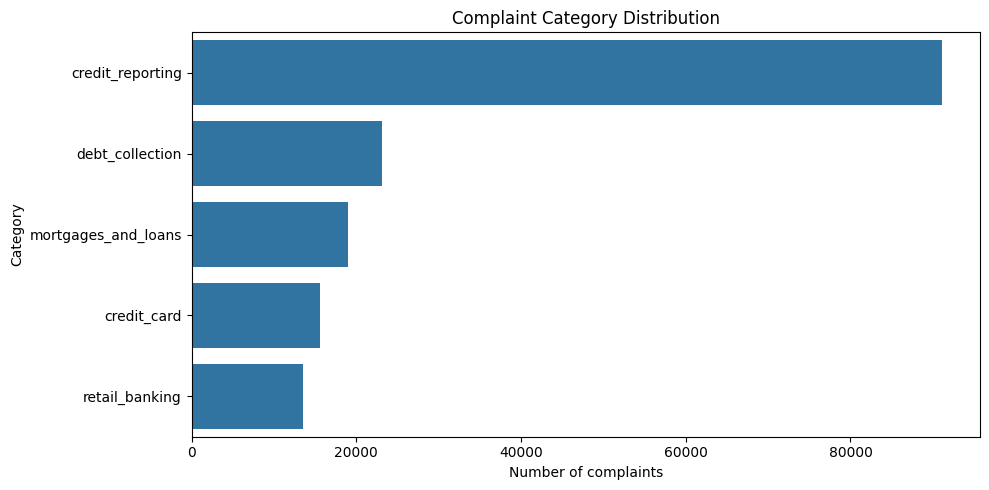

In [8]:
# Inspect class distribution
class_counts = df["label"].value_counts()
print(class_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.values, y=class_counts.index, orient="h")
plt.title("Complaint Category Distribution")
plt.xlabel("Number of complaints")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


In [9]:
# Option A: Cap very large classes and drop extremely rare classes to reduce imbalance
MIN_SAMPLES_PER_CLASS = 200   # drop categories with fewer than this many examples
MAX_SAMPLES_PER_CLASS = 5000  # cap dominant categories to this many examples

valid_labels = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index
df = df[df["label"].isin(valid_labels)].reset_index(drop=True)

df = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), MAX_SAMPLES_PER_CLASS), random_state=SEED))
      .reset_index(drop=True)
)

print("Shape after rebalancing:", df.shape)
df["label"].value_counts()


Shape after rebalancing: (25000, 2)


/tmp/ipykernel_58/2852855712.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_SAMPLES_PER_CLASS), random_state=SEED))


label
credit_card            5000
credit_reporting       5000
debt_collection        5000
mortgages_and_loans    5000
retail_banking         5000
Name: count, dtype: int64

In [10]:
# Option B: Compute class weights (used later for the from-scratch models)
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])
NUM_CLASSES = df["label_id"].nunique()

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["label_id"]),
    y=df["label_id"],
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Number of classes:", NUM_CLASSES)
print("Class weights:", class_weight_dict)


Number of classes: 5
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


## 4. Text Preprocessing

Steps: lowercasing → remove punctuation, numbers, and special characters → remove stopwords →
lemmatization.


In [11]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Clean a single complaint narrative."""
    text = text.lower()                                   # lowercasing
    text = re.sub(r"[^a-z\s]", " ", text)                  # remove punctuation, numbers, special chars
    text = re.sub(r"\s+", " ", text).strip()               # collapse whitespace
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]    # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]      # lemmatization
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()


,text,clean_text
0,saturday make sevice appointment mother give c...,saturday make sevice appointment mother give c...
1,early opened dispute transaction citibank cred...,early opened dispute transaction citibank cred...
2,received call pandemic started bank america re...,received call pandemic started bank america re...
3,cancelled account based response email problem...,cancelled account based response email problem...
4,tjmaxx refusing give card middle initial middl...,tjmaxx refusing give card middle initial middl...


In [12]:
# Drop rows that became empty after cleaning
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
print("Final dataset shape:", df.shape)


Final dataset shape: (25000, 4)


## 5. Train / Validation / Test Split

In [14]:
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["clean_text"], df["label_id"], test_size=0.30, random_state=SEED, stratify=df["label_id"]
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train:", len(X_train_text), "Val:", len(X_val_text), "Test:", len(X_test_text))


Train: 17500 Val: 3750 Test: 3750


## 6. Tokenization & Padding

Convert text into integer sequences and pad them to a fixed length for the SimpleRNN, LSTM,
and GRU models.


In [15]:
VOCAB_SIZE = 20000
MAX_LEN = 150
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

def to_padded_sequences(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_seq = to_padded_sequences(X_train_text)
X_val_seq = to_padded_sequences(X_val_text)
X_test_seq = to_padded_sequences(X_test_text)

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print("X_train_seq shape:", X_train_seq.shape)


X_train_seq shape: (17500, 150)


## 7. Model Architectures (SimpleRNN, LSTM, GRU)

In [17]:
EMBEDDING_DIM = 128

def build_rnn_model(rnn_layer_class, units=64, bidirectional=False):
    """Generic builder for SimpleRNN / LSTM / GRU classifiers."""
    model = Sequential()
    model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
    rnn = rnn_layer_class(units, return_sequences=False)
    model.add(Bidirectional(rnn) if bidirectional else rnn)
    model.add(Dropout(0.3))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(NUM_CLASSES, activation="softmax"))
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)


### 7.1 SimpleRNN

In [18]:
simplernn_model = build_rnn_model(SimpleRNN, units=64)
simplernn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1784804454.961751      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784804454.968000      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_rnn = simplernn_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
   
)


Epoch 1/10
 13/274 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2150 - loss: 1.6053

I0000 00:00:1784804467.376033     146 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.2157 - loss: 1.6087 - val_accuracy: 0.2472 - val_loss: 1.5922
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2327 - loss: 1.6005 - val_accuracy: 0.2208 - val_loss: 1.6035
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2290 - loss: 1.5948 - val_accuracy: 0.2347 - val_loss: 1.5948
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2715 - loss: 1.5322 - val_accuracy: 0.2461 - val_loss: 1.5775
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3098 - loss: 1.4526 - val_accuracy: 0.2419 - val_loss: 1.6207
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3350 - loss: 1.3809 - val_accuracy: 0.2416 - val_loss: 1.6837
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3533 - loss: 1.3630 - val_accuracy: 0.2392 - val_loss: 1.7694
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3559 - loss: 1.3567 - val_accuracy: 0.24

### 7.2 LSTM

In [20]:
lstm_model = build_rnn_model(LSTM, units=64)
lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_lstm = lstm_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
)


Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.2358 - loss: 1.5931 - val_accuracy: 0.2512 - val_loss: 1.5783
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2758 - loss: 1.5193 - val_accuracy: 0.2947 - val_loss: 1.4886
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3914 - loss: 1.3019 - val_accuracy: 0.5400 - val_loss: 1.0532
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6266 - loss: 0.8864 - val_accuracy: 0.6784 - val_loss: 0.8330
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7498 - loss: 0.6958 - val_accuracy: 0.7763 - val_loss: 0.7082
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7848 - loss: 0.6580 - val_accuracy: 0.7813 - val_loss: 0.7097
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8219 - loss: 0.5948 - val_accuracy: 0.7952 - val_loss: 0.6932
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8617 - loss: 0.4822 - val_accu

### 7.3 GRU

In [22]:
gru_model = build_rnn_model(GRU, units=64)
gru_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_gru = gru_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
)


Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.2285 - loss: 1.5967 - val_accuracy: 0.2533 - val_loss: 1.5890
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3208 - loss: 1.4748 - val_accuracy: 0.3768 - val_loss: 1.3238
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2694 - loss: 1.5207 - val_accuracy: 0.2403 - val_loss: 1.5574
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3921 - loss: 1.3008 - val_accuracy: 0.5992 - val_loss: 0.8773
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6879 - loss: 0.7698 - val_accuracy: 0.7851 - val_loss: 0.6560
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8366 - loss: 0.5139 - val_accuracy: 0.8184 - val_loss: 0.5771
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8823 - loss: 0.3824 - val_accuracy: 0.8117 - val_loss: 0.6575
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9076 - loss: 0.3033 - val_accu

## 8. Fine-Tuned Transformer (HuggingFace)

We fine-tune a lightweight pretrained transformer (`distilbert-base-uncased`) for sequence
classification. Swap `MODEL_NAME` for any other HuggingFace checkpoint if needed.


In [24]:
MODEL_NAME = "distilbert-base-uncased"

hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Build HuggingFace Datasets directly from the (uncleaned) text; transformers do their own
# subword tokenization, so heavy manual cleaning is optional here — raw text with light cleaning works well.
train_df = pd.DataFrame({"text": X_train_text.values, "label": y_train.values})
val_df = pd.DataFrame({"text": X_val_text.values, "label": y_val.values})
test_df = pd.DataFrame({"text": X_test_text.values, "label": y_test.values})

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)

def tokenize_batch(batch):
    return hf_tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds = val_ds.map(tokenize_batch, batched=True)
test_ds = test_ds.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/17500 [00:00<?, ? examples/s]

Map:   0%|          | 0/3750 [00:00<?, ? examples/s]

Map:   0%|          | 0/3750 [00:00<?, ? examples/s]

In [25]:
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES
)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

training_args = TrainingArguments(
    output_dir="./transformer_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=hf_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.046875,1.020363,0.828000,0.827745
2,0.846597,0.907507,0.852533,0.852147
3,0.684561,0.914992,0.856267,0.855944


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1641, training_loss=1.0002223798808785, metrics={'train_runtime': 496.1603, 'train_samples_per_second': 105.813, 'train_steps_per_second': 3.307, 'total_flos': 2037347885555280.0, 'train_loss': 1.0002223798808785, 'epoch': 3.0})

## 9. Model Evaluation

Evaluate every model on the held-out **test set** using Accuracy, Precision, Recall, F1-score,
and a Confusion Matrix.


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
--- SimpleRNN ---
                     precision    recall  f1-score   support

        credit_card       0.28      0.04      0.08       750
   credit_reporting       0.22      0.95      0.36       750
    debt_collection       0.33      0.05      0.08       750
mortgages_and_loans       0.35      0.08      0.13       750
     retail_banking       0.24      0.05      0.08       750

           accuracy                           0.23      3750
          macro avg       0.29      0.23      0.15      3750
       weighted avg       0.29      0.23      0.15      3750



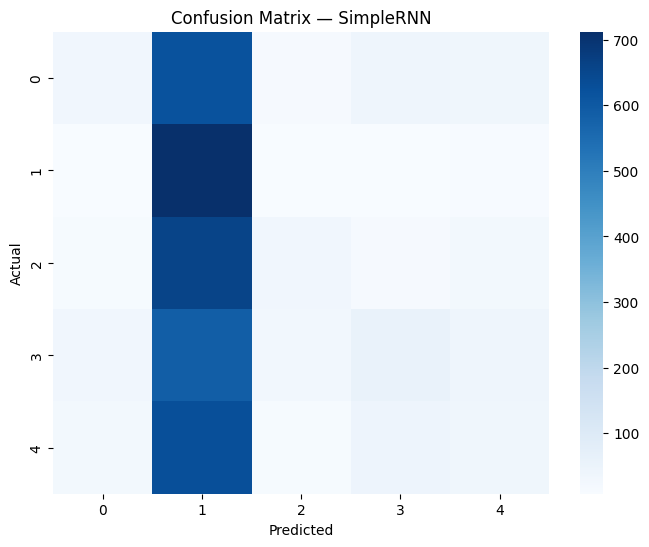

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
--- LSTM ---
                     precision    recall  f1-score   support

        credit_card       0.72      0.86      0.78       750
   credit_reporting       0.76      0.81      0.78       750
    debt_collection       0.85      0.76      0.80       750
mortgages_and_loans       0.85      0.79      0.82       750
     retail_banking       0.89      0.81      0.85       750

           accuracy                           0.81      3750
          macro avg       0.81      0.81      0.81      3750
       weighted avg       0.81      0.81      0.81      3750



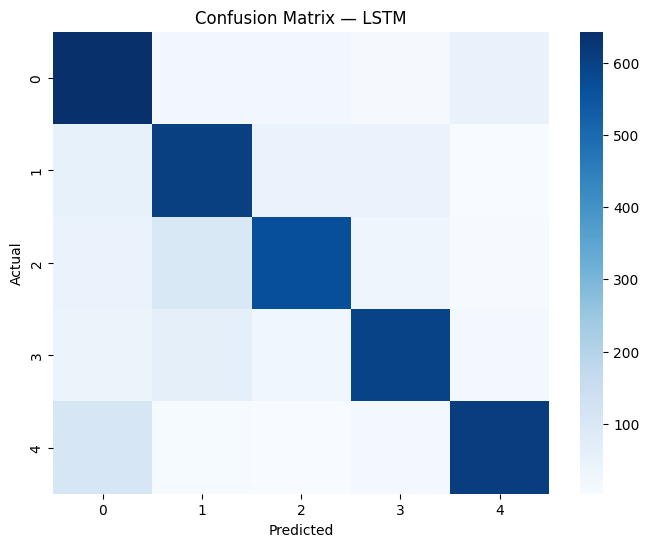

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
--- GRU ---
                     precision    recall  f1-score   support

        credit_card       0.74      0.79      0.77       750
   credit_reporting       0.84      0.77      0.81       750
    debt_collection       0.79      0.79      0.79       750
mortgages_and_loans       0.79      0.83      0.81       750
     retail_banking       0.85      0.82      0.84       750

           accuracy                           0.80      3750
          macro avg       0.80      0.80      0.80      3750
       weighted avg       0.80      0.80      0.80      3750



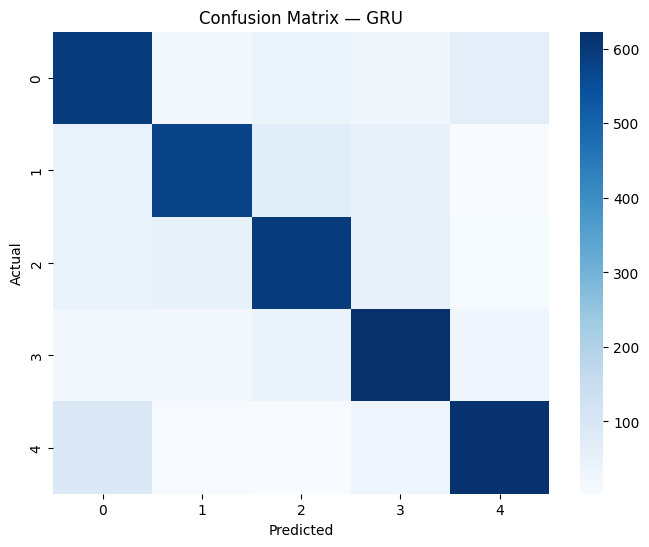

In [26]:
def evaluate_keras_model(model, X_test_seq, y_test_true, model_name):
    probs = model.predict(X_test_seq)
    preds = np.argmax(probs, axis=1)
    return summarize_results(y_test_true, preds, model_name)

def summarize_results(y_true, y_pred, model_name):
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    print(f"--- {model_name} ---")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return results

results_list = []
results_list.append(evaluate_keras_model(simplernn_model, X_test_seq, y_test, "SimpleRNN"))
results_list.append(evaluate_keras_model(lstm_model, X_test_seq, y_test, "LSTM"))
results_list.append(evaluate_keras_model(gru_model, X_test_seq, y_test, "GRU"))


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


--- Fine-tuned Transformer ---
                     precision    recall  f1-score   support

        credit_card       0.83      0.85      0.84       750
   credit_reporting       0.83      0.82      0.83       750
    debt_collection       0.87      0.81      0.84       750
mortgages_and_loans       0.86      0.87      0.86       750
     retail_banking       0.87      0.92      0.89       750

           accuracy                           0.85      3750
          macro avg       0.85      0.85      0.85      3750
       weighted avg       0.85      0.85      0.85      3750



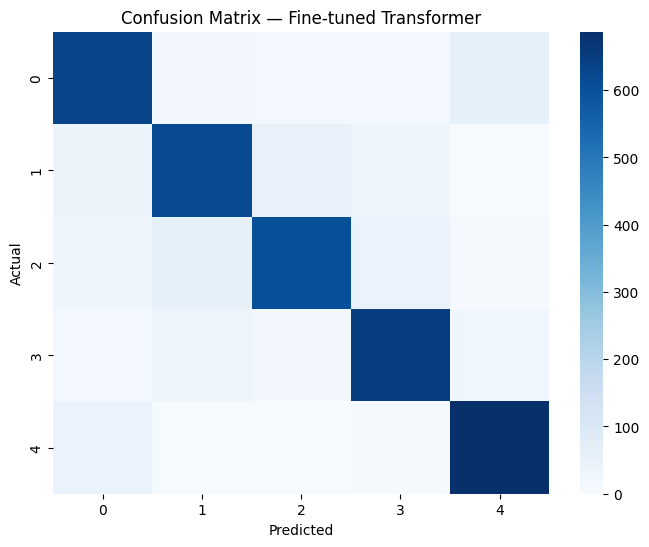

In [27]:
# Evaluate the fine-tuned transformer on the test set
transformer_preds = trainer.predict(test_ds)
transformer_pred_labels = np.argmax(transformer_preds.predictions, axis=1)
results_list.append(summarize_results(y_test.values, transformer_pred_labels, "Fine-tuned Transformer"))


## 10. Compare Model Performance

                        accuracy  precision    recall        f1
model                                                          
Fine-tuned Transformer  0.851467   0.851585  0.851467  0.851146
LSTM                    0.805333   0.812305  0.805333  0.806358
GRU                     0.802133   0.804058  0.802133  0.802459
SimpleRNN               0.233600   0.285758  0.233600  0.145651


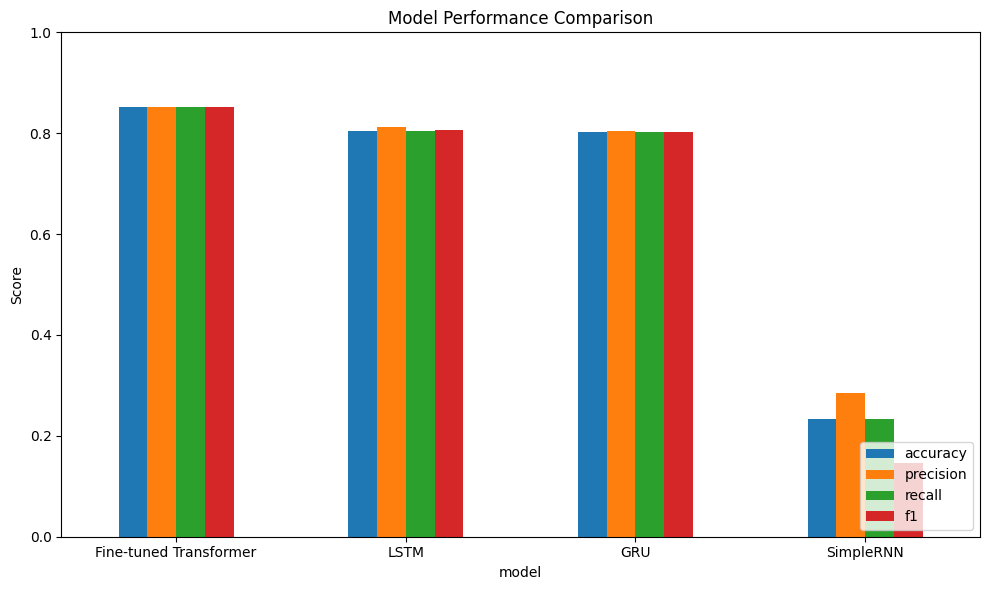

In [28]:
comparison_df = pd.DataFrame(results_list).set_index("model")
comparison_df = comparison_df.sort_values("f1", ascending=False)
print(comparison_df)

comparison_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [29]:
best_model_name = comparison_df["f1"].idxmax()
print(f"Best-performing model: {best_model_name}")


Best-performing model: Fine-tuned Transformer


## 11. Classify New Customer Complaints With the Best Model

In [30]:
def predict_complaint_category(text: str, use_transformer: bool = True):
    """
    Predict the category of a new complaint narrative.
    """
    if use_transformer:
        import torch
        device = next(transformer_model.parameters()).device  # نفس device الموديل (GPU أو CPU)

        inputs = hf_tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN)
        inputs = {k: v.to(device) for k, v in inputs.items()}  # <-- السطر الجديد المهم

        with torch.no_grad():
            logits = transformer_model(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()[0]
    else:
        cleaned = clean_text(text)
        seq = to_padded_sequences([cleaned])
        probs = gru_model.predict(seq)[0]

    pred_id = int(np.argmax(probs))
    pred_label = label_encoder.inverse_transform([pred_id])[0]
    confidence = float(probs[pred_id])
    return pred_label, confidence

## 12. Save Artifacts for Deployment

Save whichever model performed best, along with the tokenizer/label encoder needed to reproduce
predictions in the Gradio app.


In [31]:
import pickle

os.makedirs("deployment_artifacts", exist_ok=True)

# Save the label encoder (needed to map prediction ids back to category names)
with open("deployment_artifacts/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# --- If the Transformer won ---
transformer_model.save_pretrained("deployment_artifacts/transformer_model")
hf_tokenizer.save_pretrained("deployment_artifacts/transformer_model")

# --- If a Keras RNN-family model won instead (uncomment the winner) ---
# simplernn_model.save("deployment_artifacts/best_model.h5")
# lstm_model.save("deployment_artifacts/best_model.h5")
# gru_model.save("deployment_artifacts/best_model.h5")
# with open("deployment_artifacts/tokenizer.pkl", "wb") as f:
#     pickle.dump(tokenizer, f)

print("Artifacts saved to ./deployment_artifacts")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Artifacts saved to ./deployment_artifacts


## 13. Deployment — Gradio Web App

This cell builds an interactive Gradio interface: the user types a complaint narrative and gets
back the predicted category + confidence score. Run this cell after loading the saved artifacts
above (in the same notebook, or in a separate `app.py` for deployment).


In [33]:
# Imports needed for the deployment cell (add these if running this cell on its own,
# e.g. in a fresh session or a separate notebook)
import pickle
import numpy as np
import torch
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MAX_LEN = 150  # must match the value used during training/tokenization
# Load the saved tokenizer and fine-tuned model from disk
loaded_tokenizer = AutoTokenizer.from_pretrained("deployment_artifacts/transformer_model")
loaded_model = AutoModelForSequenceClassification.from_pretrained("deployment_artifacts/transformer_model")
loaded_model.eval()  # set the model to evaluation mode (disables dropout, etc.)

# Explicitly choose a device (GPU if available, otherwise CPU) and move the model to it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.to(device)

# Load the label encoder used to map prediction ids back to category names
with open("deployment_artifacts/label_encoder.pkl", "rb") as f:
    loaded_label_encoder = pickle.load(f)


def gradio_predict(complaint_text):
    """
    Takes a raw complaint narrative, runs it through the fine-tuned transformer,
    and returns the predicted category along with a confidence score.
    """
    # Tokenize the input text and get PyTorch tensors
    inputs = loaded_tokenizer(
        complaint_text, return_tensors="pt", truncation=True, max_length=MAX_LEN
    )

    # Move every tensor in the inputs dict to the same device as the model
    # (fixes "Expected all tensors to be on the same device" errors)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Run inference without tracking gradients (faster, less memory)
    with torch.no_grad():
        logits = loaded_model(**inputs).logits

    # Convert logits to probabilities; move back to CPU before converting to NumPy
    probs = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()[0]

    # Get the predicted class id, decode it back to a label, and get its confidence
    pred_id = int(np.argmax(probs))
    pred_label = loaded_label_encoder.inverse_transform([pred_id])[0]
    confidence = float(probs[pred_id])

    return pred_label, f"{confidence:.2%}"


# Build the Gradio interface
demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=5, label="Complaint narrative", placeholder="Describe your complaint here..."
    ),
    outputs=[
        gr.Textbox(label="Predicted category"),
        gr.Textbox(label="Confidence score"),
    ],
    title="Consumer Complaint Classifier",
    description="Enter a customer complaint below to predict its category using the fine-tuned model.",
)

# debug=True prints the real Python traceback in the notebook if something fails,
# instead of just showing a generic error in the browser
demo.launch(share=True, debug=True)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://e4954d94dfd9a9de31.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://e4954d94dfd9a9de31.gradio.live


### Deployment steps (summary)

1. **Pick the winning model** from the comparison table in Section 10 (usually the fine-tuned
   Transformer, but check your own results).
2. **Export the artifacts**: the model weights (Transformer folder, or the Keras `.h5` file),
   the tokenizer (HuggingFace tokenizer or the Keras `Tokenizer` object), and the `LabelEncoder`
   — all saved in Section 12.
3. **Wrap inference in a single function** (`gradio_predict`) that: takes raw text →
   preprocesses/tokenizes it the same way as training → runs the model → decodes the label →
   returns category + confidence.
4. **Build the Gradio `Interface`**: one text input (`Textbox`) for the complaint, two outputs
   (predicted category, confidence score).
5. **Launch locally** with `demo.launch()` to test, then `demo.launch(share=True)` for a
   temporary public link, or deploy permanently to **Hugging Face Spaces** by pushing the
   `app.py` + `requirements.txt` + saved model folder to a new Space (`gradio` SDK).
6. **requirements.txt** for the Space should include: `gradio`, `transformers`, `torch`,
   `scikit-learn`, `pandas`, `numpy`.
7. **Test with real/edge-case complaints** (very short text, mixed categories, typos) before
   sharing the link.


In [34]:
# ============================================================
# Save ALL artifacts needed for deployment, then zip them
# into ONE file so you can download it easily from Kaggle.
# Run this cell in the SAME notebook/session where the models
# were trained (it needs simplernn_model, lstm_model, gru_model,
# transformer_model, tokenizer, hf_tokenizer, label_encoder to
# already exist in memory).
# ============================================================

import os
import pickle
import shutil

ARTIFACTS_DIR = "/kaggle/working/deployment_artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ------------------------------------------------------------------
# 1. Label encoder (needed by every model, always required)
# ------------------------------------------------------------------
with open(f"{ARTIFACTS_DIR}/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
print("Saved: label_encoder.pkl")

# ------------------------------------------------------------------
# 2. Fine-tuned Transformer + its tokenizer
#    (this is the one you'll actually deploy on Hugging Face Spaces)
# ------------------------------------------------------------------
transformer_model.save_pretrained(f"{ARTIFACTS_DIR}/transformer_model")
hf_tokenizer.save_pretrained(f"{ARTIFACTS_DIR}/transformer_model")
print("Saved: transformer_model/ (weights + tokenizer)")

# ------------------------------------------------------------------
# 3. Keras RNN-family models (SimpleRNN / LSTM / GRU)
#    Optional — only needed if you want to keep/compare them too.
#    Comment out any you don't want to save.
# ------------------------------------------------------------------
simplernn_model.save(f"{ARTIFACTS_DIR}/simplernn_model.h5")
lstm_model.save(f"{ARTIFACTS_DIR}/lstm_model.h5")
gru_model.save(f"{ARTIFACTS_DIR}/gru_model.h5")
print("Saved: simplernn_model.h5, lstm_model.h5, gru_model.h5")

# The Keras Tokenizer (needed only if you plan to use the Keras models,
# NOT needed for the Transformer, which has its own tokenizer above)
with open(f"{ARTIFACTS_DIR}/keras_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("Saved: keras_tokenizer.pkl")

# ------------------------------------------------------------------
# 4. Save the comparison results table too, for reference
# ------------------------------------------------------------------
comparison_df.to_csv(f"{ARTIFACTS_DIR}/model_comparison_results.csv")
print("Saved: model_comparison_results.csv")

# ------------------------------------------------------------------
# 5. Zip everything into one downloadable file
# ------------------------------------------------------------------
zip_path = "/kaggle/working/deployment_artifacts"
shutil.make_archive(zip_path, "zip", ARTIFACTS_DIR)
print(f"\nAll artifacts zipped to: {zip_path}.zip")
print("Go to the 'Output' panel on the right side of the Kaggle notebook,")
print("find 'deployment_artifacts.zip', and click the download icon.")

Saved: label_encoder.pkl


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: transformer_model/ (weights + tokenizer)
Saved: simplernn_model.h5, lstm_model.h5, gru_model.h5
Saved: keras_tokenizer.pkl
Saved: model_comparison_results.csv

All artifacts zipped to: /kaggle/working/deployment_artifacts.zip
Go to the 'Output' panel on the right side of the Kaggle notebook,
find 'deployment_artifacts.zip', and click the download icon.
